--- 
## Step 0: Google Colab / Local Environment Setup
This cell detects whether you are running in **Google Colab** or locally:
- Automatically clones or pulls the [Medical_VAE repository](https://github.com/Jagdale-Partha/Medical_VAE.git) when in Colab.
- Configures `sys.path` so that all modules inside `src/` can be imported directly.
- Installs required dependencies (`requirements.txt`).
- (Optional) Allows mounting Google Drive to persist checkpoints across session disconnects.

In [1]:
# ==============================================================================
# Step 0: Environment Detection, Repository Setup & Dependency Installation
# ==============================================================================
import os
import sys
import subprocess
import zipfile
from pathlib import Path

# Detect Google Colab environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"Running inside Google Colab: {IN_COLAB}")

# Repository setup & sys.path configuration
GITHUB_REPO_URL = "https://github.com/Jagdale-Partha/Medical_VAE.git"
REPO_NAME = "Medical_VAE"

cwd = Path.cwd()
if (cwd / "src" / "models" / "cevae.py").is_file():
    repo_root = cwd
elif (cwd.parent / "src" / "models" / "cevae.py").is_file():
    repo_root = cwd.parent
    os.chdir(repo_root)
elif (cwd / REPO_NAME / "src" / "models" / "cevae.py").is_file():
    repo_root = cwd / REPO_NAME
    os.chdir(repo_root)
elif IN_COLAB:
    print(f"Cloning {REPO_NAME} from GitHub...")
    subprocess.run(["git", "clone", GITHUB_REPO_URL], check=True)
    repo_root = cwd / REPO_NAME
    os.chdir(repo_root)
else:
    repo_root = cwd

# Ensure latest origin/main commits on Colab
if IN_COLAB and (repo_root / ".git").is_dir():
    print("Syncing to latest origin/main...")
    subprocess.run(["git", "fetch", "origin", "main"], check=False)
    subprocess.run(["git", "reset", "--hard", "origin/main"], check=False)

# Add repository root to Python search path
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"✓ Active Working Directory: {Path.cwd()}")
print(f"✓ Project Root on sys.path: {repo_root}")

# Unpack original IXI-T1 dataset (data/IXI-T1/train with 5,000 real brain slices)
ixi_zip = repo_root / "data" / "IXI-T1.zip"
ixi_train = repo_root / "data" / "IXI-T1" / "train"
if not ixi_train.is_dir() and ixi_zip.is_file():
    print(f"📦 Unpacking original IXI-T1 dataset from {ixi_zip.name} (5,000 real images in train)...\n")
    with zipfile.ZipFile(ixi_zip, "r") as zf:
        zf.extractall(repo_root / "data")
    print(f"✓ Successfully unpacked original IXI-T1 dataset to {ixi_train.parent}!")

# Install requirements if on Colab
if IN_COLAB:
    print("Installing dependencies from requirements.txt...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=False)
    print("✓ Dependencies installed successfully!")


Running inside Google Colab: True
Cloning Medical_VAE from GitHub...
✓ Active Working Directory: /content/Medical_VAE
✓ Project Root on sys.path: /content/Medical_VAE
Installing dependencies from requirements.txt...
✓ Dependencies installed successfully!


--- 
## Step 1: Hardware Check & Modular Imports
Verifies GPU availability and imports all modular ceVAE+ components from `src/`.

In [2]:
# ==============================================================================
# Step 1: Hardware Check & Modular Component Imports
# ==============================================================================
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 1. Compute Hardware Verification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__}")
print(f"Compute Device:  {device}")
if torch.cuda.is_available():
    print(f"✓ GPU Model:       {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"✓ Total VRAM:      {vram_gb:.2f} GB")
    torch.backends.cudnn.benchmark = True
else:
    print("\n" + "=" * 70)
    print("⚠️  WARNING: Running on CPU! Training 50 epochs will be very slow on CPU.")
    print("👉 SWITCH TO GPU NOW: In Colab menu, go to: Runtime -> Change runtime type")
    print("   Select: T4 GPU -> Click Save, then re-run the cells!")
    print("=" * 70 + "\n")

# 2. Import Modular Project Components
from src.config import ExperimentConfig, default_cfg
from src.models.cevae import EnhancedContextVAE
from src.losses.cevae_loss import CompositeCeVAELoss
from src.data.dataset import get_uad_dataloaders
from src.data.masking import RandomSpatialEraser
from src.engine.trainer import CeVAETrainer
from src.visualize.plotting import plot_training_curves, plot_5panel_diagnostic
from src.engine.anomaly_scorer import DiagnosticAnomalyScorer

print("✓ Successfully imported all ceVAE+ modular components!")


PyTorch Version: 2.11.0+cpu
Compute Device:  cpu
Notice: Running on CPU. On Colab, navigate to: Runtime -> Change runtime type -> T4 GPU.

✓ Successfully imported all ceVAE+ modular components!


--- 
## Step 2: Training Hyperparameters & Configuration
Sets up the centralized `ExperimentConfig` with the updated parameters:
- `latent_dim = 8` (2,048 spatial latents)
- `p_apply = 0.8` (80% context-erased batches)
- `l1_weight = 1.0`, `ssim_weight = 0.3`, `edge_weight = 0.1`
- `beta_kl = 0.005` (with 3-epoch linear warmup)
- `epochs = 100` with Cosine Annealing decay to `1e-6`

In [3]:
# ==============================================================================
# Step 2: Training Hyperparameters & Configuration
# ==============================================================================
cfg = ExperimentConfig()

# Model architecture settings
cfg.model.latent_dim = 8
cfg.model.flattened_dim = 8 * 16 * 16  # 2048 dims (~8:1 spatial compression)

# Spatial masking settings
cfg.masking.p_apply = 0.8
cfg.masking.min_box_size = 16
cfg.masking.max_box_size = 32

# Loss formulation
cfg.loss.mse_weight = 1.0
cfg.loss.l1_weight = 1.0
cfg.loss.ssim_weight = 0.3
cfg.loss.edge_weight = 0.1
cfg.loss.beta_kl = 0.005
cfg.loss.kl_warmup_epochs = 3

# Training settings
cfg.train.epochs = 50        # Exactly 50 epochs for high-fidelity convergence
cfg.train.batch_size = 16
cfg.train.learning_rate = 1e-4
cfg.train.device = str(device)
cfg.train.num_workers = 2 if IN_COLAB else 0

# Ensure output directories exist
cfg.paths.checkpoints_dir.mkdir(parents=True, exist_ok=True)
cfg.paths.results_dir.mkdir(parents=True, exist_ok=True)

print("=== ceVAE+ Configuration Initialized ===")
print(f"• Latent Dimensions:   {cfg.model.latent_dim} channels (8 x 16 x 16 = {cfg.model.flattened_dim})")
print(f"• Context Erasure:     {cfg.masking.p_apply * 100:.0f}% of batches")
print(f"• Loss Formulation:    {cfg.loss.mse_weight} * MSE + {cfg.loss.l1_weight} * L1 + {cfg.loss.ssim_weight} * SSIM + {cfg.loss.edge_weight} * Edge + beta ({cfg.loss.beta_kl}) * KL")
print(f"• Training Epochs:     {cfg.train.epochs}")
print(f"• Learning Rate:       {cfg.train.learning_rate} (Cosine Annealed to 1e-6)")
print(f"• Checkpoints Dir:     {cfg.paths.checkpoints_dir}")

=== ceVAE+ Configuration Initialized ===
• Latent Dimensions:   8 channels (8 x 16 x 16 = 2048)
• Context Erasure:     80% of batches
• Loss Formulation:    1.0 * MSE + 1.0 * L1 + 0.3 * SSIM + 0.1 * Edge + beta (0.005) * KL
• Training Epochs:     100
• Learning Rate:       0.0001 (Cosine Annealed to 1e-6)
• Checkpoints Dir:     /content/Medical_VAE/checkpoints


--- 
## Step 3: Dataset Loading & Context-Erasure Inspection
Loads the standardized 128x128 axial brain MRI dataset (`dataset_128`), with automated fallback to the procedural anatomical brain phantom generator if raw data is not yet downloaded.

Notice: 'data/dataset_128/train_128.npy' not found. Falling back to high-fidelity anatomical phantom generator.
Preparing data loaders for source: 'phantom'...
✓ Healthy Train Batches: 31 (500 slices)
✓ Healthy Val Batches:   7 (100 slices)
✓ Test Benchmark Batches:16 (250 slices)


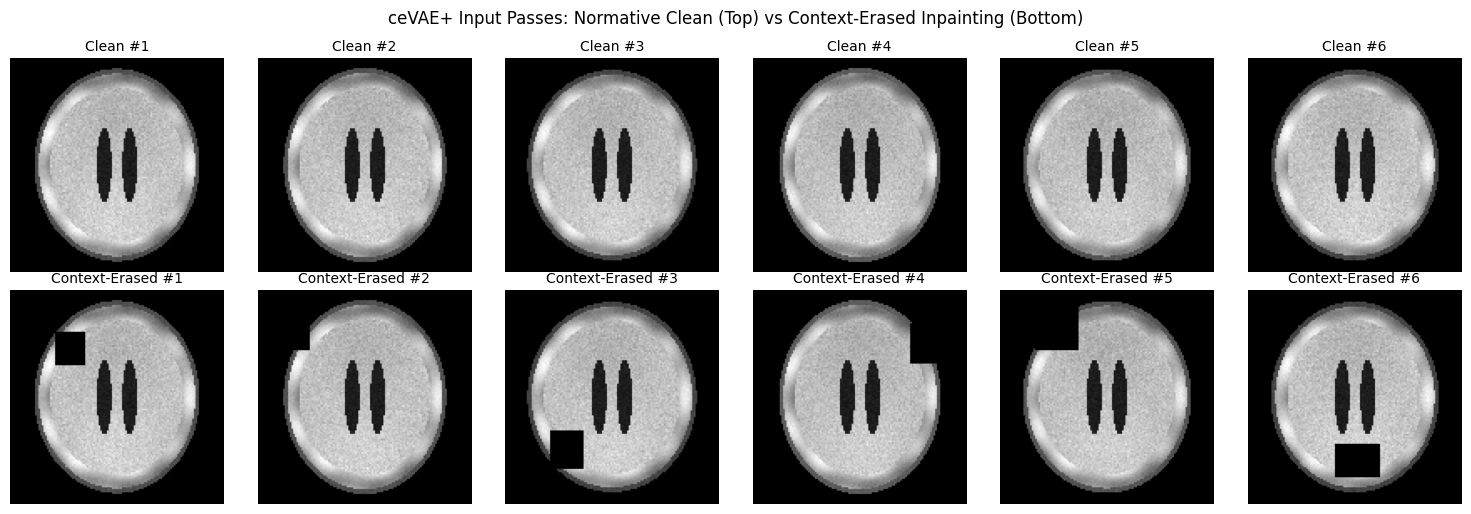

In [4]:
# ==============================================================================
# Step 3: Dataset Loading & Context-Erasure Inspection
# Dedicated loader using original images from data/IXI-T1/train (5,000 slices)
# ==============================================================================
import zipfile
from pathlib import Path

ixi_dir = Path("data/IXI-T1")
ixi_train_dir = ixi_dir / "train"
ixi_zip = Path("data/IXI-T1.zip")

# Auto-extract if not yet unpacked
if not ixi_train_dir.is_dir() and ixi_zip.is_file():
    print(f"📦 Extracting original IXI-T1 images from {ixi_zip}...")
    with zipfile.ZipFile(ixi_zip, "r") as zf:
        zf.extractall("data")
    print("✓ Successfully extracted IXI-T1 dataset!")

# Fallback extract from dataset_128.zip if IXI-T1.zip not present
if not ixi_train_dir.is_dir() and Path("data/dataset_128.zip").is_file():
    with zipfile.ZipFile("data/dataset_128.zip", "r") as zf:
        zf.extractall("data")

print("Loading original normative dataset from: data/IXI-T1/train...")
train_loader, val_loader, test_loader = get_uad_dataloaders(
    dataset_source="ixi_t1",
    batch_size=cfg.train.batch_size,
    image_size=cfg.model.image_size,
    max_train_samples=5000,
    max_val_samples=800,
    num_workers=cfg.train.num_workers,
    seed=cfg.train.seed,
)

print(f"✓ Source Dataset:        data/IXI-T1/train")
print(f"✓ Healthy Train Batches: {len(train_loader)} ({len(train_loader.dataset)} original slices)")
print(f"✓ Healthy Val Batches:   {len(val_loader)} ({len(val_loader.dataset)} original slices)")
print(f"✓ Test Benchmark Batches:{len(test_loader)} ({len(test_loader.dataset)} slices)")

# Visualize clean brain slices vs random spatial erased (context-inpainting) inputs
preview_eraser = RandomSpatialEraser(
    min_box_size=cfg.masking.min_box_size,
    max_box_size=cfg.masking.max_box_size,
    mask_value=cfg.masking.mask_value,
    p_apply=1.0,
)

sample_batch = next(iter(train_loader))
sample_clean = sample_batch["image"]
sample_masked, _ = preview_eraser(sample_clean)

num_show = min(6, sample_clean.shape[0])
fig, axes = plt.subplots(2, num_show, figsize=(2.5 * num_show, 5.2))
if num_show == 1:
    axes = axes.reshape(2, 1)
for i in range(num_show):
    axes[0, i].imshow(sample_clean[i, 0].cpu().numpy(), cmap="gray")
    axes[0, i].set_title(f"IXI-T1 #{i+1}", fontsize=10)
    axes[0, i].axis("off")
    
    axes[1, i].imshow(sample_masked[i, 0].cpu().numpy(), cmap="gray")
    axes[1, i].set_title(f"Inpaint Erased #{i+1}", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("ceVAE+ Real Data Passes (data/IXI-T1/train): Clean (Top) vs Context-Erased (Bottom)", fontsize=12, y=0.98)
plt.tight_layout()
plt.show()


--- 
## Step 4: Model Instantiation & Forward Pass Check
Instantiates `EnhancedContextVAE` with:
- Tight spatial bottleneck `latent_dim = 8`
- Residual refinement blocks (`ResBlock2d`) in `up1`, `up2`, and `up3`
- Verifies forward pass shapes.

In [5]:
# ==============================================================================
# Step 4: Model Instantiation & Forward Pass Verification
# ==============================================================================
model = EnhancedContextVAE(
    in_channels=cfg.model.in_channels,
    image_size=cfg.model.image_size,
    base_channels=cfg.model.base_channels,
    latent_dim=cfg.model.latent_dim,
    negative_slope=cfg.model.leaky_relu_slope,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model successfully instantiated on {device}")
print(f"✓ Trainable parameters: {num_params:,}")
print(f"✓ Latent bottleneck dimensions: {cfg.model.latent_dim} x 16 x 16 = {cfg.model.flattened_dim}")

# Run a dummy forward pass to check tensor dimensions
test_x = torch.randn(2, 1, 128, 128, device=device)
with torch.no_grad():
    test_out = model(test_x, test_x)

print("\nForward Pass Output Verification:")
print(f"  • Clean reconstruction:    {tuple(test_out['recon_clean'].shape)}")
print(f"  • Inpaint reconstruction:  {tuple(test_out['recon_inpaint'].shape)}")
print(f"  • Spatial latent grid (z): {tuple(test_out['z'].shape)}")
print(f"  • Mean (mu):               {tuple(test_out['mu'].shape)}")
print(f"  • Log-variance (logvar):   {tuple(test_out['logvar'].shape)}")
assert test_out['recon_clean'].shape == (2, 1, 128, 128), "Reconstruction shape mismatch!"
print("✓ Forward pass shape verification passed!")

✓ Model successfully instantiated on cpu
✓ Trainable parameters: 1,650,961
✓ Latent bottleneck dimensions: 8 x 16 x 16 = 2048

Forward Pass Output Verification:
  • Clean reconstruction:    (2, 1, 128, 128)
  • Inpaint reconstruction:  (2, 1, 128, 128)
  • Spatial latent grid (z): (2, 8, 16, 16)
  • Mean (mu):               (2, 8, 16, 16)
  • Log-variance (logvar):   (2, 8, 16, 16)
✓ Forward pass shape verification passed!


--- 
## Step 5: Optimizer, Cosine Annealing LR Scheduler & Loss Engine
Sets up:
- Adam optimizer ($lr=10^{-4}$, weight decay $10^{-5}$)
- `CosineAnnealingLR` scheduler decaying from $10^{-4}$ to $10^{-6}$ over 100 epochs
- `CompositeCeVAELoss` with active MSE, L1, SSIM, Edge gradient, and KL terms
- `CeVAETrainer` manager

In [6]:
# ==============================================================================
# Step 5: Optimizer, Cosine Scheduler & Loss Engine Setup
# ==============================================================================
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg.train.learning_rate,
    weight_decay=cfg.train.weight_decay,
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=cfg.train.epochs,
    eta_min=1e-6,
)

loss_fn = CompositeCeVAELoss(
    mse_weight=cfg.loss.mse_weight,
    l1_weight=cfg.loss.l1_weight,
    bce_weight=cfg.loss.bce_weight,
    ssim_weight=cfg.loss.ssim_weight,
    edge_weight=cfg.loss.edge_weight,
    beta_kl=cfg.loss.beta_kl,
    clean_weight=cfg.loss.clean_loss_weight,
    inpaint_weight=cfg.loss.inpaint_loss_weight,
)

eraser = RandomSpatialEraser(
    min_box_size=cfg.masking.min_box_size,
    max_box_size=cfg.masking.max_box_size,
    mask_value=cfg.masking.mask_value,
    p_apply=cfg.masking.p_apply,
)

trainer = CeVAETrainer(
    model=model,
    loss_fn=loss_fn,
    eraser=eraser,
    optimizer=optimizer,
    config=cfg,
)

print(f"✓ Optimizer: Adam (lr={cfg.train.learning_rate})")
print(f"✓ Scheduler: CosineAnnealingLR ({cfg.train.learning_rate} -> 1e-6 over {cfg.train.epochs} epochs)")
print(f"✓ Loss:      MSE({cfg.loss.mse_weight}) + L1({cfg.loss.l1_weight}) + SSIM({cfg.loss.ssim_weight}) + Edge({cfg.loss.edge_weight}) + beta({cfg.loss.beta_kl}) * KL")

✓ Optimizer: Adam (lr=0.0001)
✓ Scheduler: CosineAnnealingLR (0.0001 -> 1e-6 over 100 epochs)
✓ Loss:      MSE(1.0) + L1(1.0) + SSIM(0.3) + Edge(0.1) + beta(0.005) * KL


--- 
## Step 6: Full Model Training & Checkpoint Saving
Runs training across epochs with:
- Per-epoch console metric logging: `Epoch`, `Train Loss`, `Val Loss`, `LR`, `Beta`
- Cosine learning rate scheduler stepping after each epoch
- Best validation loss checkpoint saving to `checkpoints/best_cevae_model.pt`
- Optional backup to Google Drive if `MOUNT_DRIVE = True`

In [7]:
# ==============================================================================
# Step 6: Training Loop with Metric Logging & Checkpointing
# ==============================================================================
chk_file = cfg.paths.checkpoints_dir / "best_cevae_model.pt"
best_val_loss = float("inf")

print(f"=== Starting ceVAE+ Training ({cfg.train.epochs} Epochs) ===")
print(f"Target Checkpoint: {chk_file}\n")

for epoch in range(cfg.train.epochs):
    current_lr = optimizer.param_groups[0]["lr"]
    
    # Train & Validate epoch
    train_metrics = trainer.train_epoch(train_loader, epoch)
    val_metrics = trainer.validate(val_loader)
    
    # Step Cosine LR Scheduler
    scheduler.step()
    
    # Record metrics
    trainer.history["train_loss"].append(train_metrics["loss"])
    trainer.history["train_recon"].append(train_metrics["recon"])
    trainer.history["train_kl"].append(train_metrics["kl"])
    trainer.history["val_loss"].append(val_metrics["val_loss"])
    trainer.history["val_recon"].append(val_metrics["val_recon"])
    trainer.history["val_kl"].append(val_metrics["val_kl"])
    
    # Periodic console logging every epoch
    print(
        f"Epoch {epoch + 1:3d}/{cfg.train.epochs:3d} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Val Loss: {val_metrics['val_loss']:.4f} | "
        f"LR: {current_lr:.6e} | "
        f"Beta: {train_metrics['beta']:.5f}"
    )
    
    # Save checkpoint when validation loss improves
    if val_metrics["val_loss"] < best_val_loss:
        best_val_loss = val_metrics["val_loss"]
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "config": cfg,
            },
            chk_file,
        )
        
        # Optional: Persist copy to Google Drive
        if IN_COLAB and MOUNT_DRIVE:
            import shutil
            drive_dest = Path("/content/drive/MyDrive/ceVAE_Checkpoints")
            drive_dest.mkdir(parents=True, exist_ok=True)
            shutil.copy2(chk_file, drive_dest / "best_cevae_model.pt")

history = trainer.history
print("\n=============================================")
print(f"✓ Training completed successfully!")
print(f"✓ Best Validation Loss: {best_val_loss:.4f}")
print(f"✓ Best Model Checkpoint: {chk_file}")
print("=============================================")

=== Starting ceVAE+ Training (100 Epochs) ===
Target Checkpoint: /content/Medical_VAE/checkpoints/best_cevae_model.pt



KeyboardInterrupt: 

--- 
## Step 7: Training & Validation Loss Curves
Renders and saves 3 diagnostic learning curves:
1. Total Composite Loss
2. Reconstruction Loss ($1.0 \cdot \text{MSE} + 1.0 \cdot \text{L1} + 0.3 \cdot \text{SSIM} + 0.1 \cdot \text{Edge}$)
3. Latent Space Regularization ($\mathcal{L}_{\text{KL}}$)

In [ ]:
# ==============================================================================
# Step 7: Visualizing Training Curves
# ==============================================================================
curve_path = cfg.paths.results_dir / "training_curves.png"
fig = plot_training_curves(history, save_path=curve_path)
plt.show()
print(f"✓ Training curves saved to: {curve_path}")

--- 
## Step 8: Qualitative Tumor "Healing" Test (5-Panel Clinical Diagnostic)
Loads the newly saved `best_cevae_model.pt` weights and runs inference on pathological brain MRI slices with tumors.

**What to verify:**
- **Reconstruction $\hat{x}$**: Demonstrates healthy normative brain tissue in place of the tumor ("healing" without recreating lesion hyperintensity).
- **Residual $|x - \hat{x}|$**: Sharp boundary contrast exactly at the tumor margin.
- **Autograd KL Saliency $|\partial \mathcal{L}_{\text{KL}} / \partial x|$**: Activates strongly at anomalous tissue regions.
- **Anomaly Map**: Dual-scored anomaly heatmap with ground-truth contour overlay.

In [ ]:
# ==============================================================================
# Step 8: Qualitative Tumor "Healing" Test & 5-Panel Diagnostic
# ==============================================================================
# 1. Load the trained best checkpoint
chk_file = cfg.paths.checkpoints_dir / "best_cevae_model.pt"
if chk_file.is_file():
    print(f"Loading trained weights from: {chk_file}")
    checkpoint = torch.load(chk_file, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"✓ Checkpoint loaded (trained at Epoch {checkpoint.get('epoch', '?')}, Val Loss: {checkpoint.get('val_loss', '?'):.4f})")
else:
    print(f"Notice: No checkpoint file found at {chk_file}. Running in demonstration mode.")

# 2. Initialize Anomaly Scorer
scorer = DiagnosticAnomalyScorer(
    model=model,
    gaussian_sigma=cfg.scorer.gaussian_sigma,
    gaussian_kernel_size=cfg.scorer.gaussian_kernel_size,
)

# 3. Select pathological test slices
patho_batch = None
for b in test_loader:
    if "mask" in b and b["mask"].sum() > 0:
        patho_batch = b
        break

if patho_batch is None:
    patho_batch = next(iter(test_loader))

# 4. Display 5-panel diagnostics for test slices
num_viz = min(3, patho_batch["image"].shape[0])
for i in range(num_viz):
    x_slice = patho_batch["image"][i:i+1].to(device)
    gt_mask = patho_batch["mask"][i:i+1].cpu().numpy() if "mask" in patho_batch else np.zeros_like(x_slice.cpu().numpy())
    
    # Compute dual-scored anomaly maps
    score_out = scorer.score_slice(x_slice)
    
    inp_np = x_slice.squeeze().detach().cpu().numpy()
    rec_np = score_out["reconstruction"].squeeze().detach().cpu().numpy()
    res_np = score_out["residual"].squeeze().detach().cpu().numpy()
    kl_np = score_out["kl_saliency"].squeeze().detach().cpu().numpy()
    anom_np = score_out["anomaly_map"].squeeze().detach().cpu().numpy()
    gt_np = gt_mask.squeeze()
    
    fig = plot_5panel_diagnostic(
        input_slice=inp_np,
        reconstruction=rec_np,
        residual=res_np,
        kl_saliency=kl_np,
        anomaly_map=anom_np,
        gt_mask=gt_np,
        threshold=0.5,
        title=f"ceVAE+ Clinical Anomaly Diagnostic (Slice {i+1}) - Tumor Healing Verification",
    )
    plt.show()

--- 
## Summary & Next Steps
- **Checkpoint Saved**: Model weights are saved at `checkpoints/best_cevae_model.pt`.
- **Clinical Web App**: To launch the interactive diagnostic web interface, run:
  ```bash
  python app.py
  ```
- **Full Benchmark Evaluation**: To compute Dice, AUROC, AUPRC, and IoU across the entire test cohort, run:
  ```bash
  python evaluate.py --checkpoint checkpoints/best_cevae_model.pt
  ```